/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_85234/1188867671.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_85234/1188867671.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


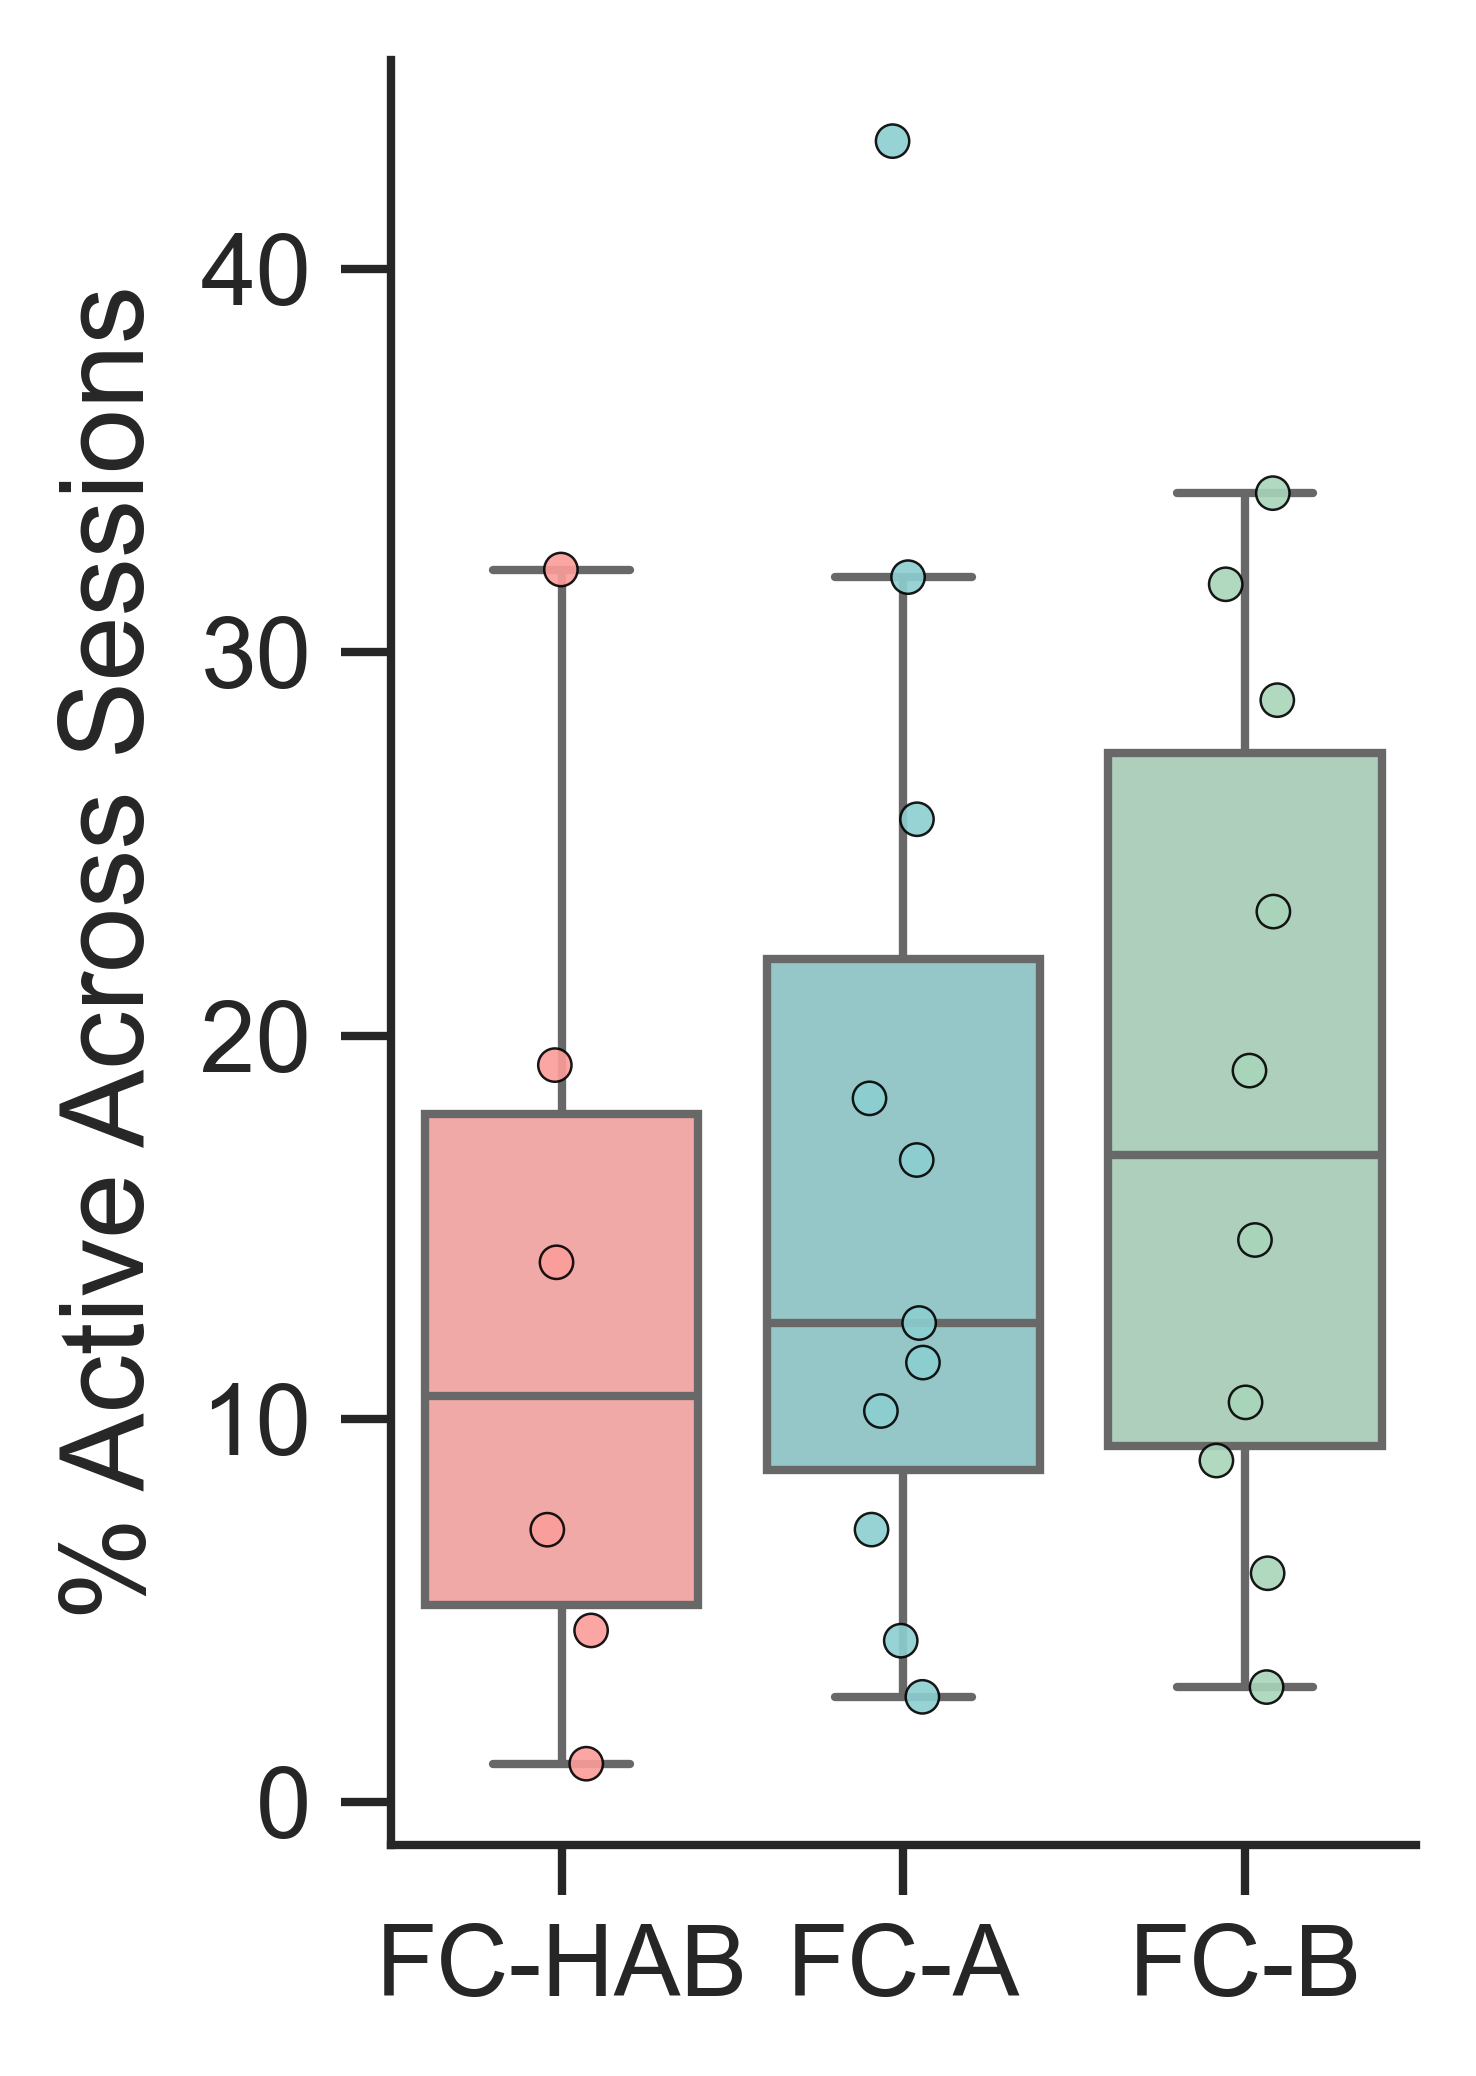

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Plot the % Active across days - normalized

# Load csv
df = pd.read_csv('/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/Figure1_background/Num_cells_reactivated/long_form_registration_data.csv')


# Calculate normalized overlap
#Across_Sessions - number of cells active on both days
#Unique_Total - total number of unique cells (FC + A + Across = 100%
df['pct_overlap'] = (df['Across_Sessions'] / df['Unique_Total']) * 100

# Order of session pairs
session_pairs = ['FC-HAB','FC-A','FC-B']

# Custom session colors
session_colors = {
    'HAB': '#FC9D9A',     # Soft Coral
    'FC':  '#B39BC8',     # Dusty Lavender
    'A':   '#8CCFD0',     # Cool Sky Blue
    'B':   '#A8D5BA'      # Warm Taupe
}

# Assign each pair a blended color (average of the two sessions)
pair_colors = {
    'FC-HAB': session_colors['HAB'],
    'FC-A':   session_colors['A'],
    'FC-B':   session_colors['B']
}

sns.set(style='ticks')
plt.rcParams.update({'font.size': 8})

plt.figure(figsize=(2.5, 3.5), dpi=600)
ax = plt.gca()

# Boxplot
sns.boxplot(
    data=df, x='Session_Pair', y='pct_overlap',
    order=session_pairs, ax=ax,
    palette=[pair_colors[s] for s in session_pairs],
    linewidth=1, showfliers = False
)

# Stripplot
sns.stripplot(
    data=df, x='Session_Pair', y='pct_overlap',
    order=session_pairs, ax=ax,
    palette=[pair_colors[s] for s in session_pairs],
    jitter=True, dodge=False,
    size=4, linewidth=0.3, edgecolor='black', alpha=0.9
)

# Labels + aesthetics
ax.set_xlabel('')
ax.set_ylabel('% Active Across Sessions', fontsize=14, weight='regular')
ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_linewidth(1)
ax.tick_params(width=1, labelsize=12)
sns.despine(ax=ax)
plt.tight_layout()
ax.grid(False)
plt.savefig('/Users/suthardr/Desktop/Revision/fig1/percent_across_session_pairs.svg')
plt.show()



In [2]:
df.to_csv('/Users/suthardr/Desktop/data.csv')

In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

df = pd.read_csv('/Users/suthardr/Desktop/data.csv')
eps = 1e-6
p = (df["pct_overlap"] / 100.0).clip(eps, 1 - eps)
df["pct_logit"] = np.log(p / (1 - p))

#Sex - supplemental
model_sex = ols('pct_logit ~ C(Session_Pair) * C(Sex)', data=df).fit()
anova_sex = sm.stats.anova_lm(model_sex, typ=2)
print("\nANOVA (logit) with Session_Pair * Sex")
print(anova_sex)

#Order - supplemental
model_order = ols('pct_logit ~ C(Session_Pair) * C(Order)', data=df).fit()
anova_order = sm.stats.anova_lm(model_order, typ=2)
print("\nANOVA (logit) with Session_Pair * Order")
print(anova_order)

#main figure
model_all = ols('pct_logit ~ C(Session_Pair)', data=df).fit()
anova_all = sm.stats.anova_lm(model_all, typ=2)
print("\nANOVA (logit) with Session_Pair")
print(anova_all)


ANOVA (logit) with Session_Pair * Sex
                           sum_sq    df         F    PR(>F)
C(Session_Pair)          0.624207   2.0  0.303566  0.741366
C(Sex)                   4.972451   1.0  4.836437  0.039205
C(Session_Pair):C(Sex)   0.240609   2.0  0.117014  0.890149
Residual                21.590579  21.0       NaN       NaN

ANOVA (logit) with Session_Pair * Order
                             sum_sq    df         F    PR(>F)
C(Session_Pair)            1.577593   2.0  0.715611  0.500434
C(Order)                   0.092514   1.0  0.083931  0.774881
C(Session_Pair):C(Order)   3.563460   2.0  1.616419  0.222360
Residual                  23.147666  21.0       NaN       NaN

ANOVA (logit) with Session_Pair
                   sum_sq    df         F    PR(>F)
C(Session_Pair)   1.53927   2.0  0.689132  0.511672
Residual         26.80364  24.0       NaN       NaN


In [4]:
figdf_simple = df.groupby(['Animal','Session_Pair'], as_index=False)['pct_overlap'].mean()


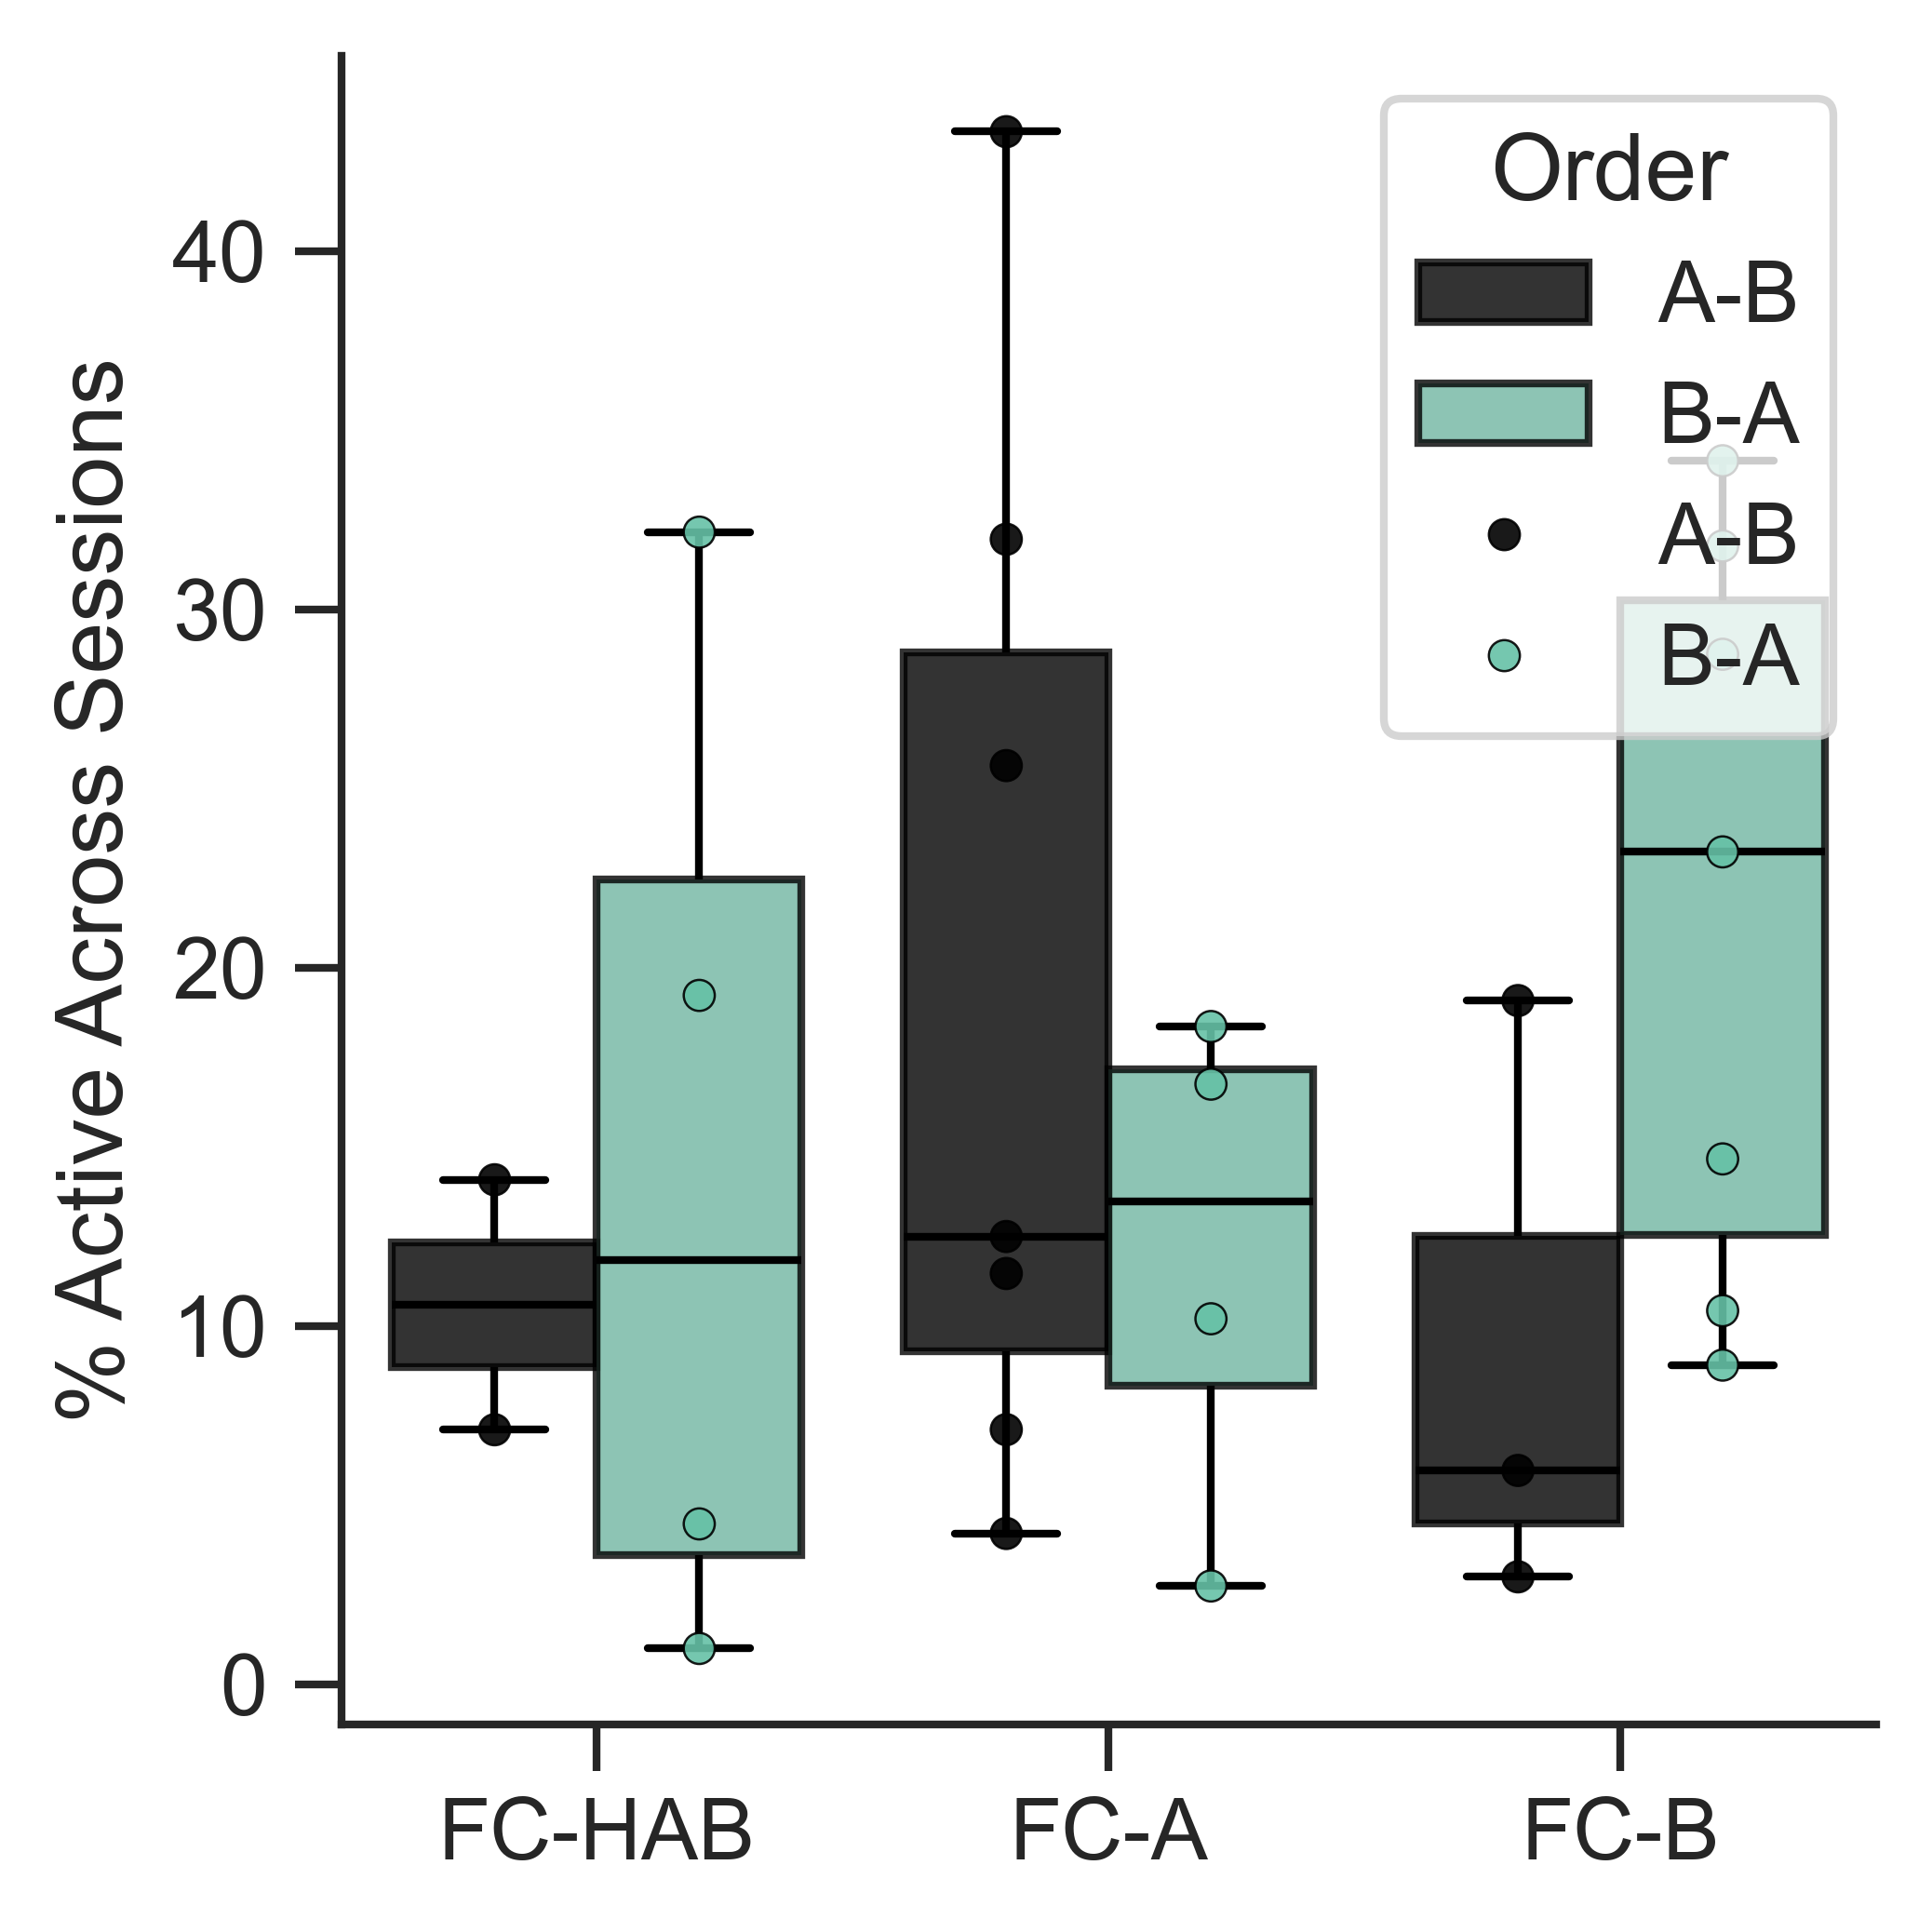

In [5]:
#Plot by Sex and Order
df = pd.read_csv('/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/Figure1_background/Num_cells_reactivated/long_form_registration_data.csv')

# % overlap with union denominator
df['pct_overlap'] = (df['Across_Sessions'] / df['Unique_Total']) * 100

pair_order = ['FC-HAB','FC-A','FC-B']

# Order colors
order_palette = {'B-A': '#66C1A6',   # blue
                 'A-B': 'black'}     # black

# Sex colors
sex_palette = {'male': '#1f77b4',    # blue
               'female': '#e377c2'}  # pink

sns.set(style='ticks')
plt.rcParams.update({'font.size': 8})

#Plot by Order (A-B) or (B-A)
plt.figure(figsize=(3.5,3.5), dpi=600)
ax = sns.boxplot(
    data=df, x='Session_Pair', y='pct_overlap',
    order=pair_order, hue='Order', boxprops=dict(alpha=0.8),
    palette=order_palette, linewidth=1
)
sns.stripplot(
    data=df, x='Session_Pair', y='pct_overlap',
    order=pair_order, hue='Order',
    palette=order_palette, dodge=True, jitter=False,
    size=4, linewidth=0.3, edgecolor='black', alpha=0.9
)
ax.set_xlabel('')
ax.set_ylabel('% Active Across Sessions', fontsize=12, weight='regular')
ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_linewidth(1)
ax.tick_params(width=1, labelsize=11)
sns.despine(ax=ax)
plt.legend(title='Order', loc='upper right')
plt.tight_layout()
plt.savefig('/Users/suthardr/Desktop/Revision/fig1/percent_across_session_pairs_byOrder.svg')
plt.show()

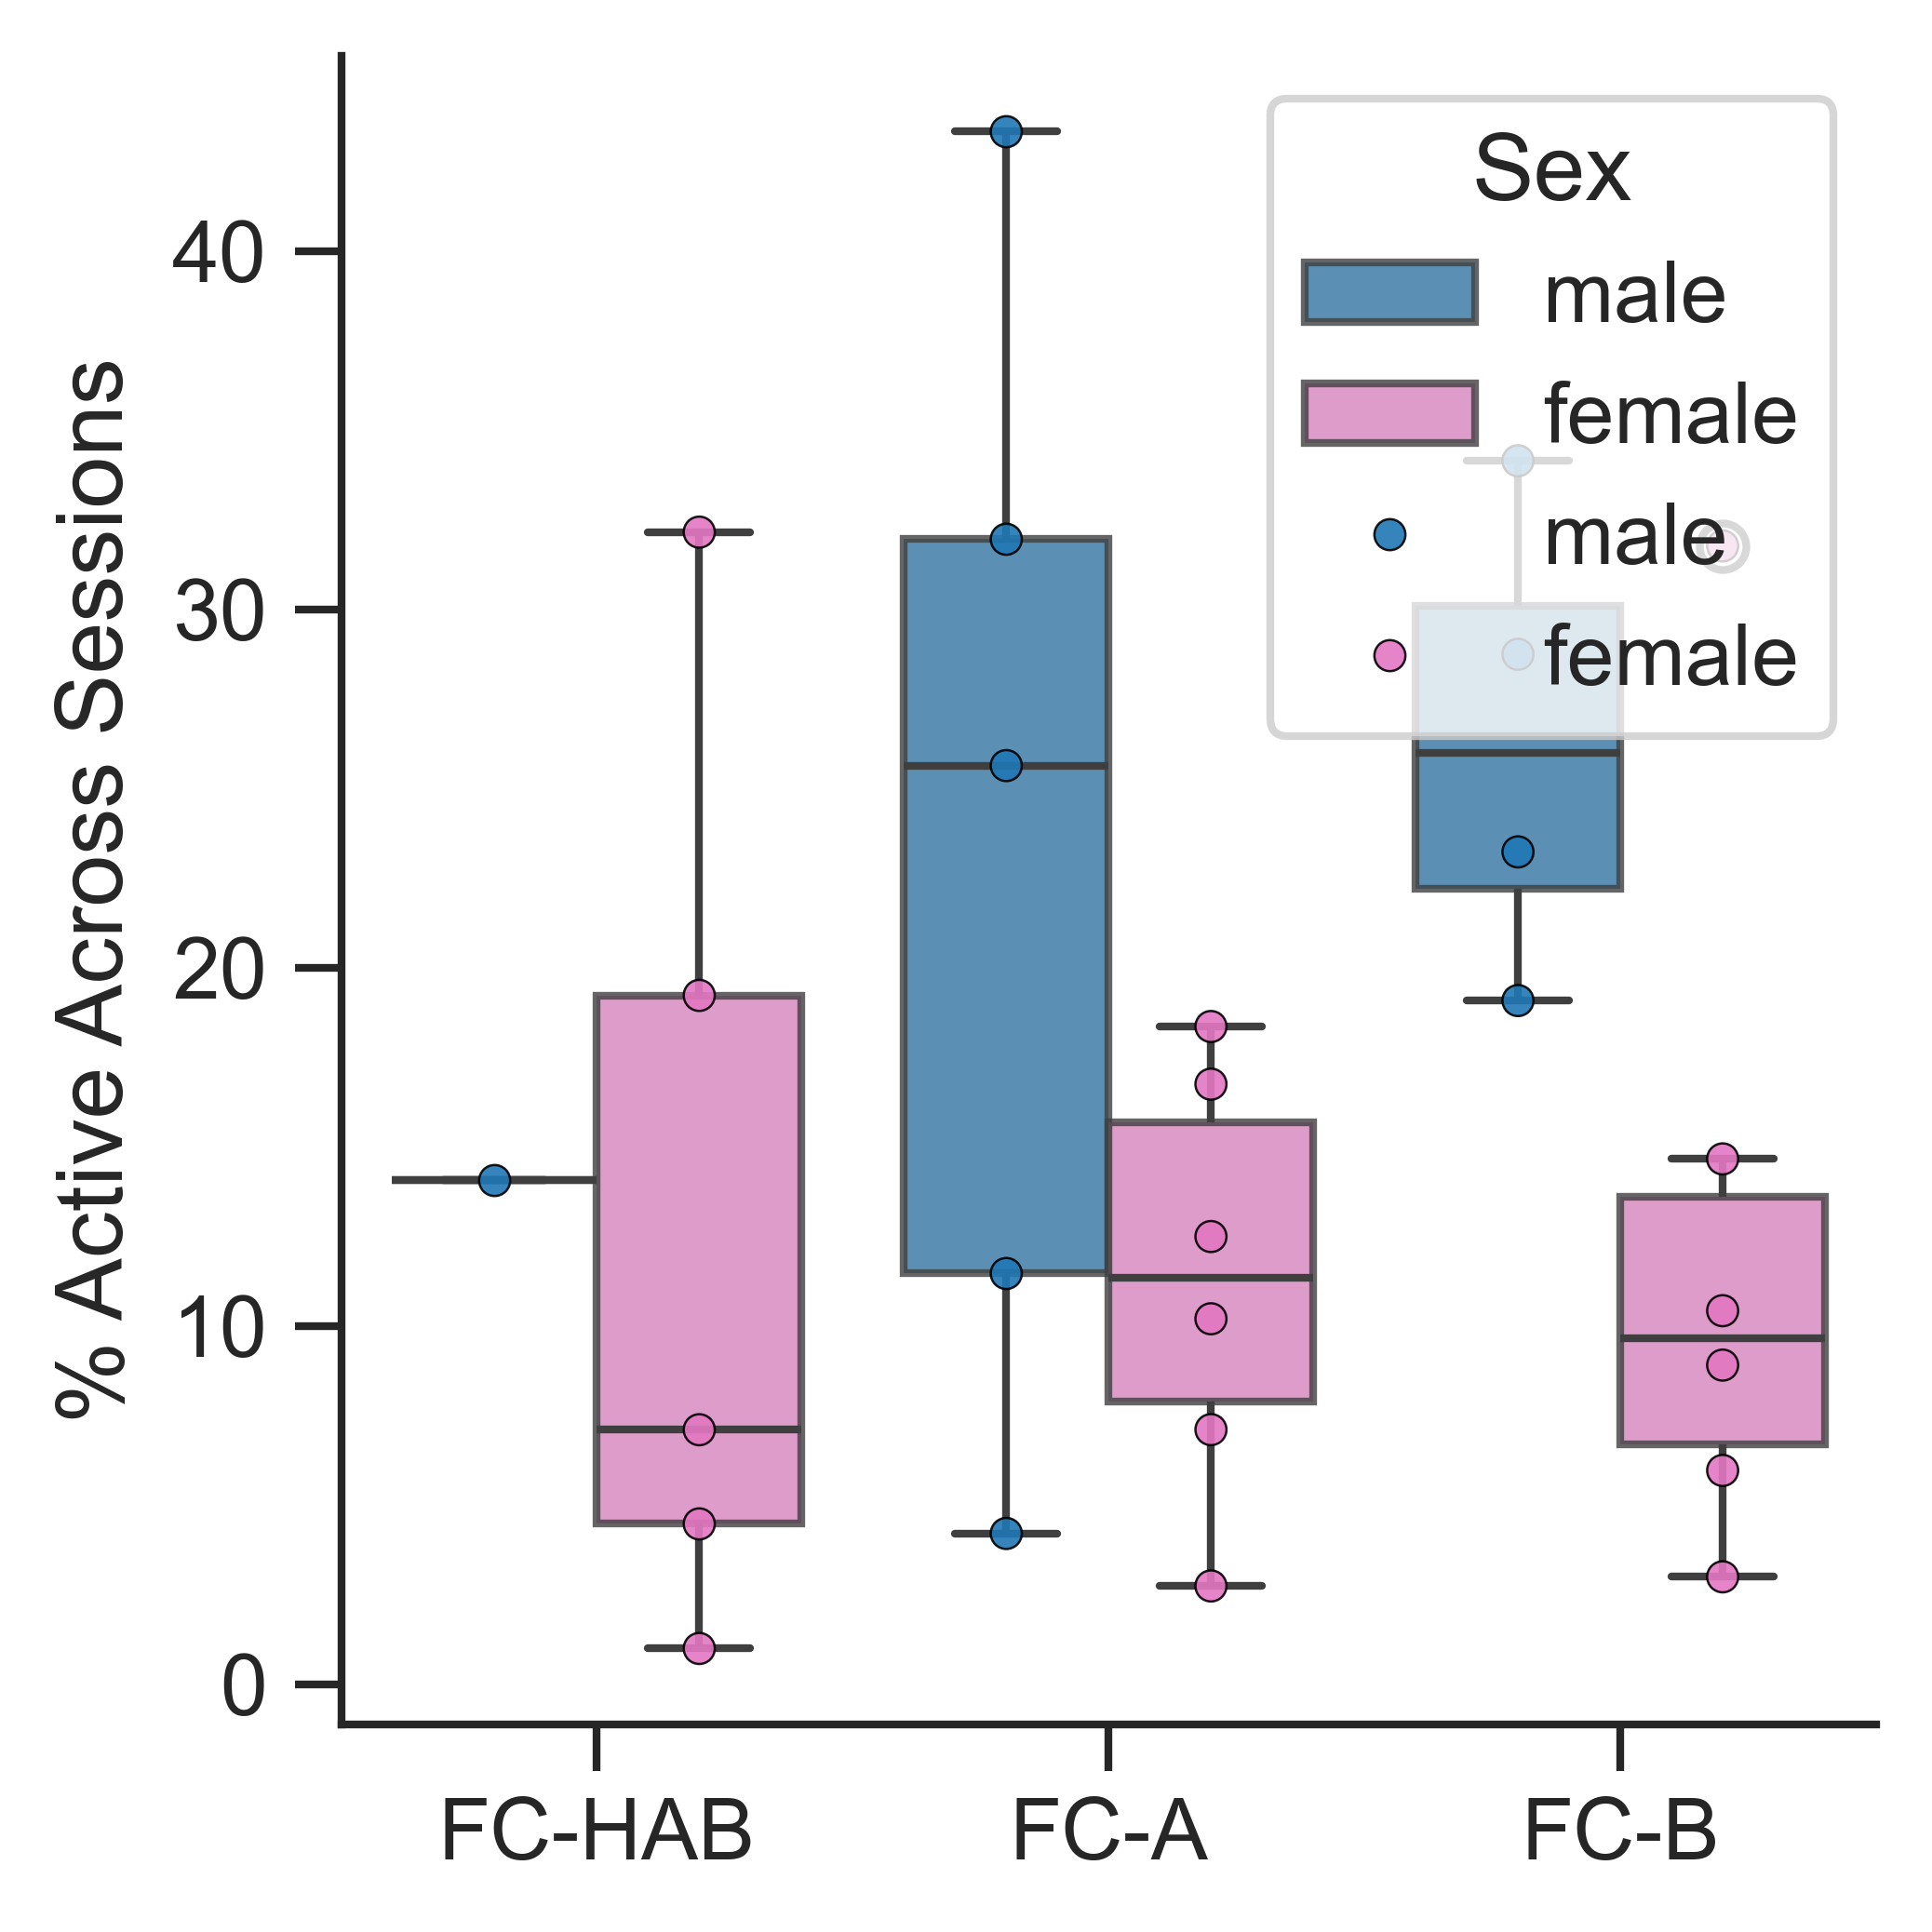

In [6]:

#Plot by Sex
plt.figure(figsize=(3.5,3.5), dpi=600)
ax = sns.boxplot(
    data=df, x='Session_Pair', y='pct_overlap',
    order=pair_order, hue='Sex', boxprops=dict(alpha=0.8),
    palette=sex_palette, linewidth=1
)
sns.stripplot(
    data=df, x='Session_Pair', y='pct_overlap',
    order=pair_order, hue='Sex',
    palette=sex_palette, dodge=True, jitter=False,
    size=4, linewidth=0.3, edgecolor='black', alpha=0.9
)
ax.set_xlabel('')
ax.set_ylabel('% Active Across Sessions', fontsize=12, weight='regular')
ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_linewidth(1)
ax.tick_params(width=1, labelsize=11)
sns.despine(ax=ax)
plt.legend(title='Sex', loc='upper right')
plt.tight_layout()
plt.savefig('/Users/suthardr/Desktop/Revision/fig1/percent_across_session_pairs_bySex.svg')
plt.show()


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/Figure1_background/Num_cells_reactivated/long_form_registration_data.csv')

#Calculate things
df['pct_unique_FC']   = (df['Unique_FC']   / df['Unique_Total']) * 100.0
df['pct_unique_Cond'] = (df['Unique_Cond'] / df['Unique_Total']) * 100.0

In [8]:
# Melt so each animal/session pair keeps the correct FC vs partner values
long = df.melt(
    id_vars=['Animal','Order','Sex','Session_Pair'],
    value_vars=['pct_unique_FC','pct_unique_Cond'],
    var_name='Day_label',
    value_name='pct_unique'
)

# Relabel Day_label to FC vs partner (A/B/HAB)
partner_map = {'FC-A':'A', 'FC-B':'B', 'FC-HAB':'HAB'}
long['Day_label'] = long.apply(
    lambda r: 'FC' if r['Day_label'] == 'pct_unique_FC' else partner_map[r['Session_Pair']],
    axis=1
)

long

,Animal,Order,Sex,Session_Pair,Day_label,pct_unique
0,astroM3,A-B,male,FC-A,FC,22.580645
1,astroM4,A-B,male,FC-A,FC,34.267241
2,astroM5,A-B,male,FC-A,FC,39.093484
3,astroM9,A-B,male,FC-A,FC,57.894737
4,astroM10,A-B,male,FC-A,FC,76.146789
5,astroF3,B-A,female,FC-A,FC,48.691099
6,astroF5,B-A,female,FC-A,FC,68.571429
7,astroF6,A-B,female,FC-A,FC,83.412322
8,astroF7,A-B,female,FC-A,FC,77.777778
9,astroF9,B-A,female,FC-A,FC,46.017699


In [9]:
long.to_csv('/Users/suthardr/Desktop/long_data.csv')

NameError: name 'ttest_rel' is not defined

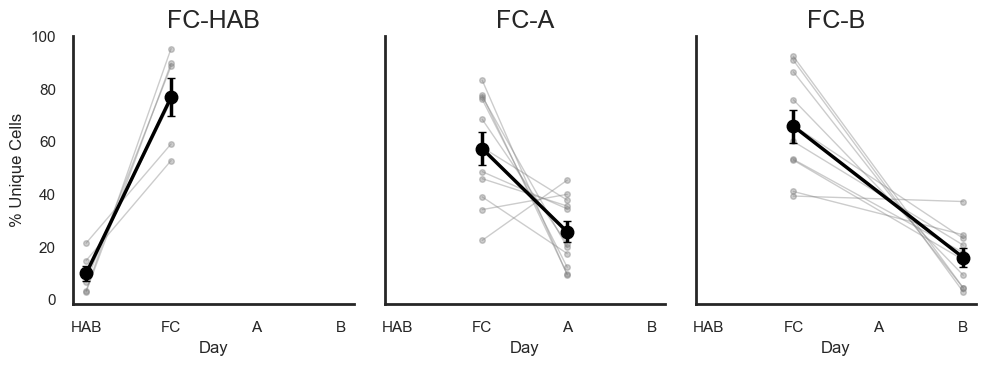

In [10]:
def plot_pct_unique_with_stats(
    long: pd.DataFrame,
    facet_order=('FC-HAB', 'FC-A', 'FC-B'),
    x_order=('HAB', 'FC', 'A', 'B'),
    context='talk'
):
    """
    Plot % unique cells by Day_label with per-animal thin lines and mean±SEM,
    faceted by Session_Pair. For each facet (FC–HAB, FC–A, FC–B), run a
    within-animal paired t-test (FC vs partner) and annotate:
      n, t, p (raw), p (Bonferroni-corrected across the 3 facets), Cohen's d (paired).
    """
    partner_map = {'FC-HAB': 'HAB', 'FC-A': 'A', 'FC-B': 'B'}
    x_order = list(x_order)
    order_key = {lab: i for i, lab in enumerate(x_order)}

    # ---- Plotting ----
    sns.set(style='white', context=context)
    g = sns.FacetGrid(
        long, col='Session_Pair', col_order=facet_order,
        sharey=True, height=4, aspect=0.85
    )

    def _panel(data, color=None, **kwargs):
        ax = plt.gca()

        # Per-animal thin lines (sorted by desired x order)
        for animal, sub in data.groupby('Animal'):
            sub = sub.sort_values('Day_label', key=lambda s: s.map(order_key))
            ax.plot(sub['Day_label'], sub['pct_unique'],
                    alpha=0.4, linewidth=1, color='grey', marker='o', ms=4)

        # Means ± SEM in fixed order (only plot available levels)
        means = data.groupby('Day_label')['pct_unique'].mean().reindex(x_order).dropna()
        sems  = data.groupby('Day_label')['pct_unique'].sem().reindex(x_order).dropna()

        if len(means) > 0:
            ax.errorbar(means.index, means.values, yerr=sems.values,
                        fmt='-o', linewidth=2.5, capsize=3, color='black')

        # Style
        ax.set_xlabel('Day', fontsize=12, weight='regular')
        ax.set_ylabel('% Unique Cells', fontsize=12, weight='regular')
        ax.spines[['right','top']].set_visible(False)
        ax.spines[['left','bottom']].set_linewidth(2)
        ax.tick_params(width=2, labelsize=11)

    g.map_dataframe(_panel)
    g.set_titles(col_template='{col_name}')

    # ---- Stats per facet (paired t-test FC vs partner) ----
    rows = []
    for sp in facet_order:
        sub = long[long['Session_Pair'] == sp]
        if sub.empty:
            rows.append(dict(Session_Pair=sp, n=0, t=np.nan, p=np.nan, d=np.nan))
            continue

        partner = partner_map[sp]
        # Wide: rows=Animal, columns=['FC', partner]; average within animal if multiple rows
        wide = (sub.pivot_table(index='Animal', columns='Day_label',
                                values='pct_unique', aggfunc='mean')
                    .dropna(subset=['FC', partner], how='any'))

        n = len(wide)
        if n == 0:
            rows.append(dict(Session_Pair=sp, n=0, t=np.nan, p=np.nan, d=np.nan))
            continue

        # Paired t-test
        tval, pval = ttest_rel(wide['FC'], wide[partner])

        # Cohen's d (paired)
        if _HAS_PG:
            try:
                dval = float(pg.ttest(wide['FC'], wide[partner], paired=True)['d'].iloc[0])
            except Exception:
                diffs = (wide['FC'] - wide[partner]).to_numpy()
                sd = diffs.std(ddof=1)
                dval = np.nan if sd == 0 else diffs.mean() / sd
        else:
            diffs = (wide['FC'] - wide[partner]).to_numpy()
            sd = diffs.std(ddof=1)
            dval = np.nan if sd == 0 else diffs.mean() / sd

        rows.append(dict(Session_Pair=sp, n=n, t=tval, p=pval, d=dval))

    stats_df = pd.DataFrame(rows)

    # Bonferroni correction across the three facets
    mask = stats_df['p'].notna()
    stats_df['p_corr'] = np.nan
    if mask.any():
        _, p_corr, _, _ = multipletests(stats_df.loc[mask, 'p'].values, method='bonferroni')
        stats_df.loc[mask, 'p_corr'] = p_corr

    # ---- Annotate each facet ----
    d_n   = dict(zip(stats_df['Session_Pair'], stats_df['n']))
    d_t   = dict(zip(stats_df['Session_Pair'], stats_df['t']))
    d_p   = dict(zip(stats_df['Session_Pair'], stats_df['p']))
    d_d   = dict(zip(stats_df['Session_Pair'], stats_df['d']))

    for ax, sp in zip(g.axes.flat, facet_order):
        n = d_n.get(sp, 0)
        if n == 0:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
            continue

        txt = (
            f"{sp.replace('-', ' vs ')} (paired t)\n"
            f"n={n}, t={d_t[sp]:.2f}, p={d_p[sp]:.4g}\n"
            f"d={d_d[sp]:.2f}"
        )
        ax.text(0.05, 0.95, txt, transform=ax.transAxes, ha='left', va='top', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7))

    plt.tight_layout()
    plt.show()
    return g, stats_df

g, stats_df = plot_pct_unique_with_stats(long)
print(stats_df)


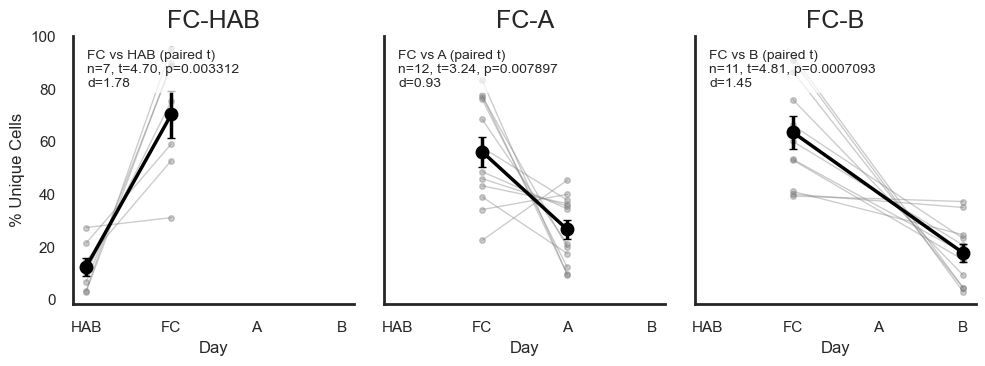

  Session_Pair   n         t         p         d    p_corr
0       FC-HAB   7  4.703996  0.003312  1.777943  0.009937
1         FC-A  12  3.238323  0.007897  0.934823  0.023692
2         FC-B  11  4.813302  0.000709  1.451265  0.002128


In [145]:
#Plots HAB,FC,A,B in order with %unique_cells for each CellReg pair in facet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

def plot_pct_unique_with_stats(
    long: pd.DataFrame,
    facet_order=('FC-HAB', 'FC-A', 'FC-B'),
    x_order=('HAB', 'FC', 'A', 'B'),
    context='talk'
):
    """
    Plot % unique cells by Day_label with per-animal thin lines and mean±SEM,
    faceted by Session_Pair. For each facet (FC–HAB, FC–A, FC–B), run a
    within-animal paired t-test (FC vs partner) and annotate:
      n, t, p (raw), p (Bonferroni-corrected across the 3 facets), Cohen's d (paired).

    Parameters
    ----------
    long : pd.DataFrame
        Must contain columns:
          - 'Animal'
          - 'Session_Pair' (values include 'FC-HAB', 'FC-A', 'FC-B')
          - 'Day_label'    (subset of {'HAB','FC','A','B'})
          - 'pct_unique'   (numeric)
    facet_order : tuple
        Order of facets (Session_Pair).
    x_order : tuple
        Fixed x-axis order shown on every facet.
    context : str
        Seaborn context (e.g., 'talk', 'paper').

    Returns
    -------
    g : seaborn.axisgrid.FacetGrid
        The plotted FacetGrid (already shown).
    stats_df : pd.DataFrame
        Table with per-facet stats (n, t, p, p_corr, d).
    """
    partner_map = {'FC-HAB': 'HAB', 'FC-A': 'A', 'FC-B': 'B'}
    x_order = list(x_order)
    order_key = {lab: i for i, lab in enumerate(x_order)}

    # ---- Plotting ----
    sns.set(style='white', context=context)
    g = sns.FacetGrid(
        long, col='Session_Pair', col_order=facet_order,
        sharey=True, height=4, aspect=0.85
    )

    def _panel(data, color=None, **kwargs):
        ax = plt.gca()

        # Per-animal thin lines (sorted by desired x order)
        for animal, sub in data.groupby('Animal'):
            sub = sub.sort_values('Day_label', key=lambda s: s.map(order_key))
            ax.plot(sub['Day_label'], sub['pct_unique'],
                    alpha=0.4, linewidth=1, color='grey', marker='o', ms=4)

        # Means ± SEM in fixed order (only plot available levels)
        means = data.groupby('Day_label')['pct_unique'].mean().reindex(x_order).dropna()
        sems  = data.groupby('Day_label')['pct_unique'].sem().reindex(x_order).dropna()

        if len(means) > 0:
            ax.errorbar(means.index, means.values, yerr=sems.values,
                        fmt='-o', linewidth=2.5, capsize=3, color='black')

        # Style
        ax.set_xlabel('Day', fontsize=12, weight='regular')
        ax.set_ylabel('% Unique Cells', fontsize=12, weight='regular')
        ax.spines[['right','top']].set_visible(False)
        ax.spines[['left','bottom']].set_linewidth(2)
        ax.tick_params(width=2, labelsize=11)

    g.map_dataframe(_panel)
    g.set_titles(col_template='{col_name}')

    # ---- Stats per facet (paired t-test FC vs partner) ----
    rows = []
    for sp in facet_order:
        sub = long[long['Session_Pair'] == sp]
        if sub.empty:
            rows.append(dict(Session_Pair=sp, n=0, t=np.nan, p=np.nan, d=np.nan))
            continue

        partner = partner_map[sp]
        # Wide: rows=Animal, columns=['FC', partner]; average within animal if multiple rows
        wide = (sub.pivot_table(index='Animal', columns='Day_label',
                                values='pct_unique', aggfunc='mean')
                    .dropna(subset=['FC', partner], how='any'))

        n = len(wide)
        if n == 0:
            rows.append(dict(Session_Pair=sp, n=0, t=np.nan, p=np.nan, d=np.nan))
            continue

        # Paired t-test
        tval, pval = ttest_rel(wide['FC'], wide[partner])

        # Cohen's d (paired)
        if _HAS_PG:
            try:
                dval = float(pg.ttest(wide['FC'], wide[partner], paired=True)['d'].iloc[0])
            except Exception:
                diffs = (wide['FC'] - wide[partner]).to_numpy()
                sd = diffs.std(ddof=1)
                dval = np.nan if sd == 0 else diffs.mean() / sd
        else:
            diffs = (wide['FC'] - wide[partner]).to_numpy()
            sd = diffs.std(ddof=1)
            dval = np.nan if sd == 0 else diffs.mean() / sd

        rows.append(dict(Session_Pair=sp, n=n, t=tval, p=pval, d=dval))

    stats_df = pd.DataFrame(rows)

    # Bonferroni correction across the three facets
    mask = stats_df['p'].notna()
    stats_df['p_corr'] = np.nan
    if mask.any():
        _, p_corr, _, _ = multipletests(stats_df.loc[mask, 'p'].values, method='bonferroni')
        stats_df.loc[mask, 'p_corr'] = p_corr

    # ---- Annotate each facet ----
    d_n   = dict(zip(stats_df['Session_Pair'], stats_df['n']))
    d_t   = dict(zip(stats_df['Session_Pair'], stats_df['t']))
    d_p   = dict(zip(stats_df['Session_Pair'], stats_df['p']))
    d_d   = dict(zip(stats_df['Session_Pair'], stats_df['d']))

    for ax, sp in zip(g.axes.flat, facet_order):
        n = d_n.get(sp, 0)
        if n == 0:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
            continue

        txt = (
            f"{sp.replace('-', ' vs ')} (paired t)\n"
            f"n={n}, t={d_t[sp]:.2f}, p={d_p[sp]:.4g}\n"
            f"d={d_d[sp]:.2f}"
        )
        ax.text(0.05, 0.95, txt, transform=ax.transAxes, ha='left', va='top', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7))

    plt.tight_layout()
    plt.show()
    return g, stats_df

g, stats_df = plot_pct_unique_with_stats(long)
print(stats_df)


/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_85234/1234222900.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_85234/1234222900.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


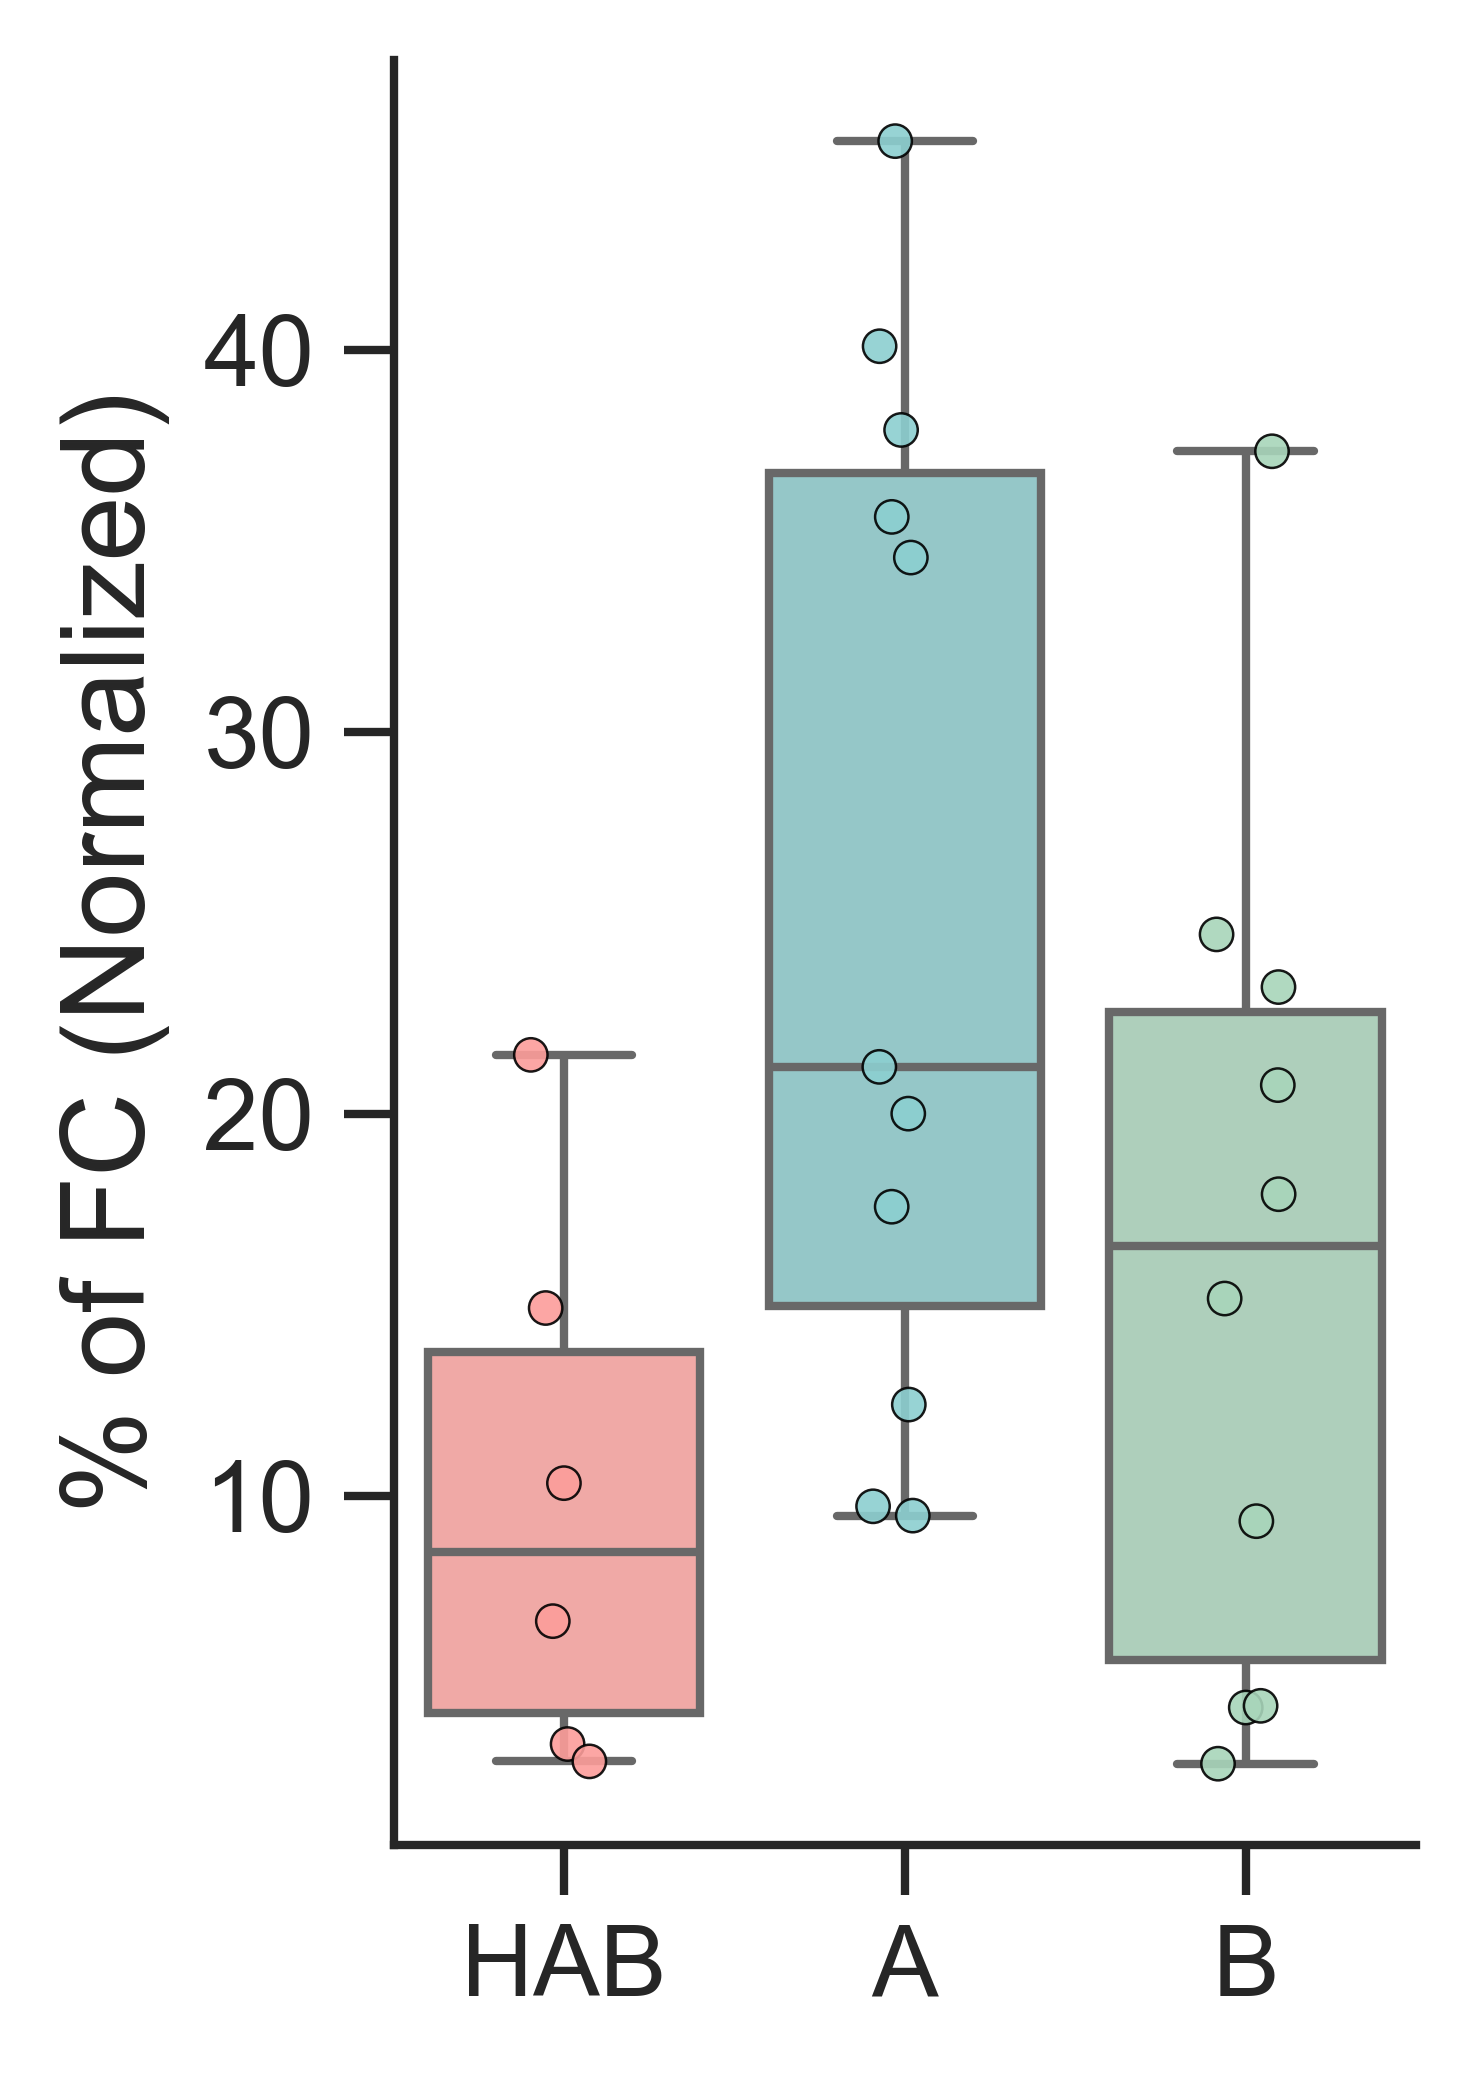

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#Figure 1
#Calculated by pct_unique for FC and each paired session
#Normalized to 100 for FC
#Shown as the %FC for each group
df = pd.read_csv('/Users/suthardr/Desktop/Revision/fig1/Normalized_UniqueCells_FC_Pair.csv')

# Order of session pairs
session = ['HAB','A','B']

# Custom session colors
session_colors = {
    'HAB': '#FC9D9A',     # Soft Coral
    'A':   '#8CCFD0',     # Cool Sky Blue
    'B':   '#A8D5BA'      # Warm Taupe
}

sns.set(style='ticks')
plt.rcParams.update({'font.size': 8})

plt.figure(figsize=(2.5, 3.5), dpi=600)
ax = plt.gca()

# Boxplot
sns.boxplot(
    data=df, x='Session', y='Normalized',
    order=session, ax=ax,
    palette=session_colors,
    linewidth=1, showfliers = False
)

# Stripplot
sns.stripplot(
    data=df, x='Session', y='Normalized',
    order=session, ax=ax,
    palette=session_colors,
    jitter=True, dodge=False,
    size=4, linewidth=0.3, edgecolor='black', alpha=0.9
)

# Labels + aesthetics
ax.set_xlabel('')
ax.set_ylabel('% of FC (Normalized)', fontsize=14, weight='regular')

ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_linewidth(1)
ax.tick_params(width=1, labelsize=12)
sns.despine(ax=ax)
plt.tight_layout()
ax.grid(False)
plt.savefig('/Users/suthardr/Desktop/percent_of_FC_unique_normalized.svg')
plt.show()

In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

#Run logit transformation on the percentage data + one-way ANOVA for groups
df = pd.read_csv('/Users/suthardr/Desktop/Revision/fig1/Normalized_UniqueCells_FC_Pair.csv')
eps = 1e-6
p = (df["Normalized"] / 100.0).clip(eps, 1 - eps)
df["Normalized_logit"] = np.log(p / (1 - p))

#main figure
model_all = ols('Normalized_logit ~ C(Session)', data=df).fit()
anova_all = sm.stats.anova_lm(model_all, typ=2)
print("\nANOVA (logit) with Session")
print(anova_all)


ANOVA (logit) with Session
               sum_sq    df         F    PR(>F)
C(Session)   6.678391   2.0  4.371176  0.024056
Residual    18.333898  24.0       NaN       NaN


In [15]:
#Session is significant - 0.042, so run multiple comparisons
import pingouin as pg

posthoc = pg.pairwise_ttests(dv='Normalized',
                             between='Session',
                             data=df,
                             padjust='bonf')  # or 'holm', 'fdr_bh'
print(posthoc)


  Contrast  A    B  Paired  Parametric         T        dof alternative  \
0  Session  A    B   False        True  1.850461  18.881673   two-sided   
1  Session  A  HAB   False        True  3.199530  14.973217   two-sided   
2  Session  B  HAB   False        True  1.325000  13.792866   two-sided   

      p-unc    p-corr p-adjust   BF10    hedges  
0  0.079958  0.239875     bonf  1.248  0.769285  
1  0.005981  0.017942     bonf  7.447  1.300933  
2  0.206703  0.620110     bonf  0.768  0.581169  


/Users/suthardr/opt/anaconda3/envs/dca1_rescue/lib/python3.10/site-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)
